# sameer khadka
## Worksheet-2
### Image Classification Using Softmax Regression

---
## Section 3.1 — Softmax & Prediction Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [2]:
def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.

    Parameters:
        z (numpy.ndarray): Logits of shape (m, n).

    Returns:
        numpy.ndarray: Softmax probability matrix of shape (m, n).
    """
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)
row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")

Softmax function passed the test case!


In [3]:
def predict_softmax(X, W, b):
    """
    Predict class labels using the trained softmax model.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        numpy.ndarray: Predicted class labels of shape (n,).
    """
    z = np.dot(X, W) + b
    probs = softmax(z)
    predicted_classes = np.argmax(probs, axis=1)
    return predicted_classes


X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])
y_pred_test = predict_softmax(X_test, W_test, b_test)
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


---
## Section 3.2 — Loss & Cost Functions

In [4]:
def loss_softmax(y_pred, y):
    """
    Compute the cross-entropy loss over all samples.

    Parameters:
        y_pred (numpy.ndarray): Predicted probabilities of shape (n, c).
        y     (numpy.ndarray): True one-hot labels of shape (n, c).

    Returns:
        float: Mean cross-entropy loss.
    """
    y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
    loss = -np.mean(np.sum(y * np.log(y_pred_clipped), axis=1))
    return loss


y_true_correct   = np.array([[1,0,0],[0,1,0],[0,0,1]])
y_pred_correct   = np.array([[0.9,0.05,0.05],[0.1,0.85,0.05],[0.05,0.1,0.85]])
y_pred_incorrect = np.array([[0.05,0.05,0.9],[0.1,0.05,0.85],[0.85,0.1,0.05]])

loss_correct   = loss_softmax(y_pred_correct,   y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, f"Test failed: {loss_correct:.4f} >= {loss_incorrect:.4f}"
print(f"Cross-Entropy Loss (Correct Predictions):   {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions):   0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


In [5]:
def cost_softmax(X, y, W, b):
    """
    Compute the average softmax cross-entropy cost over all samples.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        y (numpy.ndarray): One-hot labels of shape (n, c).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        float: Average cross-entropy cost.
    """
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
    total_loss = -np.sum(y * np.log(y_pred_clipped))
    return total_loss / n


X_correct   = np.array([[1.0,0.0],[0.0,1.0]])
y_correct   = np.array([[1,0],[0,1]])
W_correct   = np.array([[5.0,-2.0],[-3.0,5.0]])
b_correct   = np.array([0.1,0.1])

X_incorrect = np.array([[0.1,0.9],[0.8,0.2]])
y_incorrect = np.array([[1,0],[0,1]])
W_incorrect = np.array([[0.1,2.0],[1.5,0.3]])
b_incorrect = np.array([0.5,0.6])

cost_correct   = cost_softmax(X_correct,   y_correct,   W_correct,   b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, f"Test failed: {cost_incorrect} not > {cost_correct}"
print("Cost for correct prediction:  ", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cost for correct prediction:   0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


---
## Section 3.3 — Gradient Descent

In [6]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute gradients of the cost w.r.t. weights and biases.

    Parameters:
        X (numpy.ndarray): Feature matrix (n, d).
        y (numpy.ndarray): One-hot labels (n, c).
        W (numpy.ndarray): Weights (d, c).
        b (numpy.ndarray): Biases (c,).

    Returns:
        tuple: (grad_W of shape (d,c), grad_b of shape (c,))
    """
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    diff = y_pred - y
    grad_W = np.dot(X.T, diff) / n
    grad_b = np.sum(diff, axis=0) / n
    return grad_W, grad_b


X_test = np.array([[0.2,0.8],[0.5,0.5],[0.9,0.1]])
y_test = np.array([[1,0,0],[0,1,0],[0,0,1]])
W_test = np.array([[0.4,0.2,0.1],[0.3,0.7,0.5]])
b_test = np.array([0.1,0.2,0.3])

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

z_test       = np.dot(X_test, W_test) + b_test
y_pred_test  = softmax(z_test)
grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

assert np.allclose(grad_W, grad_W_manual)
assert np.allclose(grad_b, grad_b_manual)
print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


In [7]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Gradient descent to optimise weights and biases for softmax regression.

    Parameters:
        X        (numpy.ndarray): Feature matrix (n, d).
        y        (numpy.ndarray): One-hot labels (n, c).
        W        (numpy.ndarray): Initial weights (d, c).
        b        (numpy.ndarray): Initial biases (c,).
        alpha    (float): Learning rate.
        n_iter   (int): Number of iterations.
        show_cost(bool): Print cost every 100 iterations.

    Returns:
        tuple: (W, b, cost_history)
    """
    cost_history = []
    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)
        W = W - alpha * grad_W
        b = b - alpha * grad_b
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)
        if show_cost and i % 100 == 0:
            print(f"Iteration {i:4d}  |  Cost: {cost:.4f}")
    return W, b, cost_history

---
## Section 3.4 — Load & Prepare MNIST

In [8]:
def plot_sample_images(X, y):
    """
    Plots one sample image for each digit class (0-9).

    Arguments:
        X (np.ndarray): Feature matrix containing pixel values.
        y (np.ndarray): Labels corresponding to images.
    """
    plt.figure(figsize=(10, 4))
    for i, digit in enumerate(np.unique(y)):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)
        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Load MNIST CSV, normalise, split into train/test, and plot sample images.

    Arguments:
        csv_file     (str)  : Path to MNIST CSV file.
        test_size    (float): Proportion for test set.
        random_state (int)  : Random seed.

    Returns:
        X_train, X_test, y_train, y_test
    """
    df = pd.read_csv(csv_file)
    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values
    X = X / 255.0
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    plot_sample_images(X, y)
    return X_train, X_test, y_train, y_test

CSV not found — fetching MNIST via sklearn (this may take a moment)...


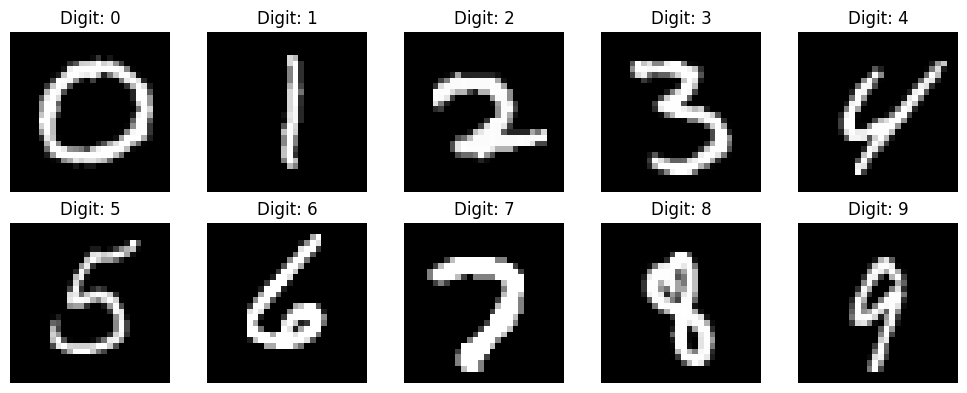

Move forward: Dimension of Feature Matrix X and label vector y matched.
Train: (56000, 784)  |  Test: (14000, 784)


In [9]:
# Load MNIST — fetch directly if no local CSV is available
try:
    X_train, X_test, y_train, y_test = load_and_prepare_mnist('mnist_train.csv')
except FileNotFoundError:
    from sklearn.datasets import fetch_openml
    print("CSV not found — fetching MNIST via sklearn (this may take a moment)...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X_raw = mnist.data / 255.0
    y_raw = mnist.target.astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y_raw, test_size=0.2, random_state=42
    )
    plot_sample_images(X_train, y_train)

assert len(X_train) == len(y_train)
print("Move forward: Dimension of Feature Matrix X and label vector y matched.")
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

---
## Section 3.5 — Train the Model

In [ ]:
encoder = OneHotEncoder(sparse_output=False)
y_train_oh = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_oh  = encoder.transform(y_test.reshape(-1, 1))

d = X_train.shape[1]
c = y_train_oh.shape[1]

W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

alpha  = 0.1
n_iter = 1000

W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train_oh, W, b, alpha, n_iter, show_cost=True
)

plt.figure(figsize=(8, 4))
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Section 3.6 — Evaluate the Model

In [10]:
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification using confusion matrix, precision, recall, and F1.

    Parameters:
        y_true (numpy.ndarray): True labels.
        y_pred (numpy.ndarray): Predicted labels.

    Returns:
        tuple: (confusion_matrix, precision, recall, f1)
    """
    cm        = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall    = recall_score(y_true, y_pred, average='weighted')
    f1        = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1


y_pred_test  = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test_oh, axis=1)

cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1-Score  : {f1:.2f}")

fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > np.max(cm) / 2 else 'black')
ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.colorbar(cax)
plt.show()

NameError: name 'W_opt' is not defined

---
## Section 4 — Linear Separability & Logistic Regression

In [ ]:
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

X_linear_separable, y_linear_separable = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)


def plot_decision_boundary(ax, model, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_decision_boundary(axes[0, 0], logistic_model_linear_separable,
                       X_train_linear, y_train_linear, 'Linearly Separable Data (Training)')
plot_decision_boundary(axes[0, 1], logistic_model_linear_separable,
                       X_test_linear, y_test_linear, 'Linearly Separable Data (Testing)')
plot_decision_boundary(axes[1, 0], logistic_model_non_linear_separable,
                       X_train_non_linear, y_train_non_linear, 'Non-Linearly Separable Data (Training)')
plot_decision_boundary(axes[1, 1], logistic_model_non_linear_separable,
                       X_test_non_linear, y_test_non_linear, 'Non-Linearly Separable Data (Testing)')

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()

---
## Written Answers

### Question 1 — Is extracting pixel values sufficient for effective feature extraction?

Raw pixel values are a reasonable starting point but are not always sufficient. Each pixel is treated as an independent feature, meaning the model ignores spatial relationships between neighbouring pixels. Pixel values are also sensitive to shifts, rotations, and lighting changes. More robust alternatives include histogram of oriented gradients (HOG), SIFT, or learned features from convolutional neural networks that capture local structure and are invariant to such transformations. For simple centred, size-normalised datasets like MNIST, pixel features work well; for more complex real-world images they tend to underperform.

---

### Question 2 — Interpretation of the decision boundary plots

For the **linearly separable dataset**, logistic regression draws a clean straight boundary that correctly separates the two classes in both the training and test sets. The coloured regions show that the model generalises well, with very few misclassified points.

For the **non-linearly separable (circles) dataset**, logistic regression still draws a straight boundary, which is fundamentally unable to capture the circular structure of the data. The two classes are arranged in concentric rings, but the linear boundary cuts through them diagonally, resulting in many misclassifications on both the training and test sets. This demonstrates the core limitation of logistic regression: it cannot model non-linear decision boundaries without feature engineering or kernel methods.

---

### Question 3 — Challenges faced

The main challenges were: (1) ensuring numerical stability in the softmax function by subtracting the row-wise maximum before exponentiation to avoid overflow; (2) correctly aligning array shapes throughout — especially keeping track of (n, d), (d, c), and (n, c) dimensions across X, W, b, and y; (3) making sure the one-hot encoding was applied consistently to both training and test labels before computing gradients and cost; and (4) choosing an appropriate learning rate — too large caused the cost to diverge, too small made convergence very slow.
